# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import seaborn as sns
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
import torch
import os
import pandas as pd
import scbiot as scb
from scbiot.utils import set_seed

import harmonypy as hm
from umap import UMAP
# %pip install scib-metrics
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

set_seed(42)

from pathlib import Path
dir = Path.cwd()
print(dir)
parent_dir = dir.parent
print(parent_dir)


scbiot version 1.0.8
Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


In [2]:
adata_path = f"{dir}/inputs/lung_atlas.h5ad"

adata = sc.read(
    adata_path,
    backup_url="https://figshare.com/ndownloader/files/24539942",
)
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [3]:
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [4]:
# sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
# sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key='batch')
# sc.pp.scale(adata)
# sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)

In [ ]:
adata, metrics = scb.ot.integrate_centroids(adata, obsm_key='X_pca', batch_key='batch', out_key='X_ot',
                                            ot_mode="balanced",
                                            n_centroids_per_batch=512,   # tune: fewer = faster, more = better fidelity
                                            max_samples_per_batch=500_000,
                                            k_interp=8,                              
                                            chunk_size=500_000,
                                            modality='rna')
print(metrics)

[baseline] KNN backend=FAISS-GPU mix=0.9646 strain=0.00349
[ot] balanced mode -> using reference='union' for symmetric mixing
[iter 01] mix=1.136 overlap0=0.817 strain=0.01335 floor~0.600 J=0.226 best_it=1
[iter 02] mix=1.286 overlap0=0.672 strain=0.04742 floor~0.606 J=0.333 best_it=2
[iter 03] mix=1.378 overlap0=0.564 strain=0.08468 floor~0.611 J=0.381 best_it=3
[iter 04] mix=1.427 overlap0=0.474 strain=0.11935 floor~0.617 J=0.362 best_it=3
[iter 05] mix=1.425 overlap0=0.484 strain=0.11688 floor~0.623 J=0.371 best_it=3
[iter 06] mix=1.437 overlap0=0.484 strain=0.11833 floor~0.629 J=0.379 best_it=3
[early stop] plateau reached.
[final] it*=3 mix=1.378 overlap0=0.564 strain=0.08468 tw=0.992
{'mix': 1.377701256855117, 'overlap0': 0.5635400414466858, 'strain': 0.08467943221330643, 'tw': 0.9919483452162694, 'it': 3, 'n_centroids': 8142}


In [6]:
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca', 'X_ot'
    varm: 'PCs'
    layers: 'counts'

In [7]:
# 1. Compute neighbors using Harmony-corrected PCA
sc.pp.neighbors(adata, use_rep='X_ot')

# 2. Run UMAP 
sc.tl.umap(adata)

# 3. Leiden clustering
sc.tl.leiden(adata, resolution=0.8, key_added='leiden_X_ot')
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'leiden_X_ot'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_X_ot'
    obsm: 'X_pca', 'X_ot', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [8]:
adata.obs['leiden_X_ot'].value_counts()

leiden_X_ot
0     3988
1     3363
2     3225
3     2880
4     2623
5     2450
6     2000
7     1876
8     1838
9     1769
10    1387
11     983
12     849
13     778
14     739
15     725
16     345
17     314
18     294
19      46
Name: count, dtype: int64

In [9]:
from sklearn.metrics import normalized_mutual_info_score

df = pd.DataFrame(adata.obsm['X_ot'], index=adata.obs.index) # adata.X.toarray()
df['batch'] = adata.obs['batch']

df['target'] = adata.obs['cell_type']
# Step 1: Get the counts of each category
category_counts = df['target'].value_counts()
# Step 2: Create a mapping of categories to numbers based on descending counts
category_mapping = {category: idx for idx, category in enumerate(category_counts.index)}
# Step 3: Map the original categorical column to the new numeric values
df['target'] = df['target'].map(category_mapping)

df['pseudo'] = adata.obs['leiden_X_ot']
# Step 1: Get the counts of each category
category_counts = df['pseudo'].value_counts()
# Step 2: Create a mapping of categories to numbers based on descending counts
category_mapping = {category: idx for idx, category in enumerate(category_counts.index)}
# Step 3: Map the original categorical column to the new numeric values
df['pseudo'] = df['pseudo'].map(category_mapping)

df = df.reset_index().set_index(['index', 'batch', 'target', 'pseudo'])

# Extract numeric labels
true_labels = df.reset_index()['target']
pred_labels = df.reset_index()['pseudo']

# Calculate NMI
nmi_score = normalized_mutual_info_score(true_labels, pred_labels)
print("NMI:", nmi_score)


NMI: 0.7350316407218206


In [10]:
# adata.write_h5ad(f'{dir}/cluster/lung/alldata.h5ad')

In [11]:
scb.pp.setup_anndata(adata, var_key='X_ot', batch_key='batch', pseudo_key='leiden_X_ot')

{'var_key': 'X_ot',
 'batch_key': 'batch',
 'pseudo_key': 'leiden_X_ot',
 'true_key': None}

In [12]:
model = scb.models.vae(adata, verbose=True)

Random seed set as 42
[Explicit labels] has_pseudo=True
[Explicit labels] batch_train/test: torch.Size([29224]) / torch.Size([3248])
[Explicit labels] pseudo_train/test: torch.Size([29224]) / torch.Size([3248])


In [13]:
model.train()

Training:   0%|          | 0/80 [00:00<?, ?it/s]

Saved whole dataset latents (N=32472)


Training:   1%|▏         | 1/80 [00:03<05:03,  3.84s/it, epoch=1/80, Train_loss=1.9259, Test_loss=1.7417]

{'Train NMI': 0.213, 'Train ARI': 0.116, 'Train ACC': 0.291, 'Train kBET': 0.924, 'Train CCR': 0.0}


Training:   2%|▎         | 2/80 [00:05<03:08,  2.42s/it, epoch=2/80, Train_loss=2.6373, Test_loss=2.3521]

...

{'Train NMI': 0.825, 'Train ARI': 0.711, 'Train ACC': 0.754, 'Train kBET': 0.239, 'Train CCR': 97.052}


Training: 100%|██████████| 80/80 [01:40<00:00,  1.12s/it, epoch=80/80, Train_loss=1.9734, Test_loss=2.0178]

{'Train NMI': 0.831, 'Train ARI': 0.749, 'Train ACC': 0.774, 'Train kBET': 0.231, 'Train CCR': 96.708}


Training: 81it [01:41,  1.26s/it, epoch=81/80, Train_loss=1.9772, Test_loss=2.0171]                        

{'Train NMI': 0.816, 'Train ARI': 0.705, 'Train ACC': 0.759, 'Train kBET': 0.238, 'Train CCR': 96.794}
Training time: 1.70 mins


In [14]:
SCBIOT_LATENT_KEY = "scBIOT"
adata.obsm[SCBIOT_LATENT_KEY] = model.get_latent_representation(n_components=50, svd_solver='arpack', random_state=42)

In [15]:
methods = ["X_ot", "scBIOT"] # , "scBIOT_OT"
leiden_methods = [f'{method}_leiden' for method in methods]

for method, leiden_method in zip(methods, leiden_methods):
    sc.pp.neighbors(adata, use_rep=method)
    sc.tl.umap(adata)
    adata.obsm[f"X_umap_{method}"] = adata.obsm["X_umap"].copy()
    sc.tl.leiden(adata, key_added=leiden_method, resolution=0.8)

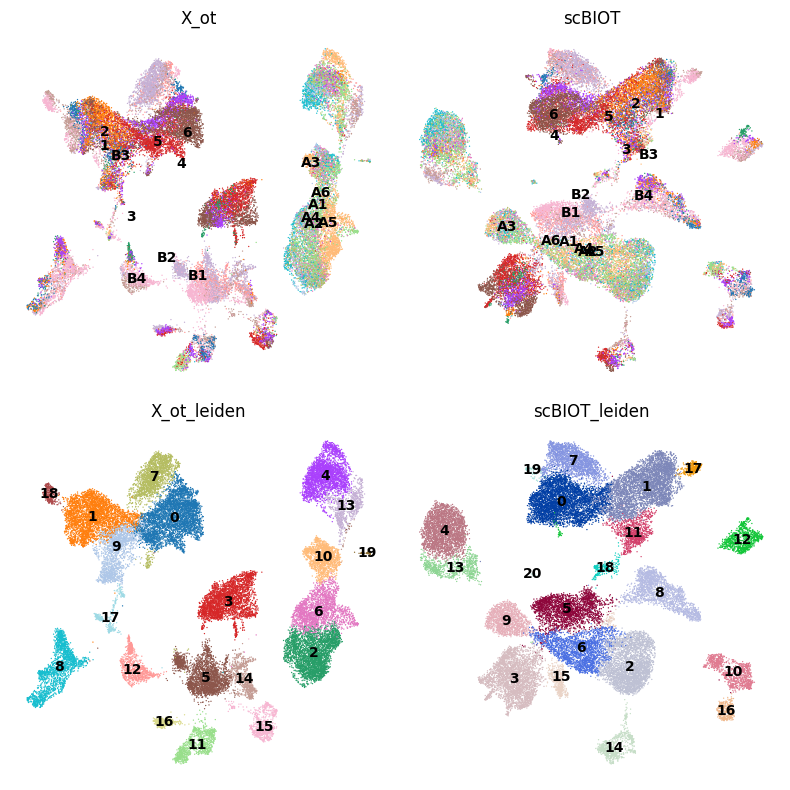

In [16]:
import matplotlib.pyplot as plt
import scanpy as sc


# 2 rows x len(methods) columns
fig, axes = plt.subplots(
    2,
    len(methods),
    figsize=(4 * len(methods), 8),
    squeeze=False  # ensures axes is a 2D array
)

for col, method in enumerate(methods):
    # 1) Top row (row=0): color by "batch"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",  # The coordinates stored in adata.obsm["X_umap_{method}"]
        color="batch",            # Assume adata.obs["batch"] exists
        frameon=False,
        ax=axes[0, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        title=f"{method}"
    )

    # 2) Bottom row (row=1): color by the Leiden clusters for this method
    leiden_key = f"{method}_leiden"
    sc.pl.embedding(
        adata,
        basis=f"X_umap_{method}",
        color=leiden_key,         # Column in adata.obs
        frameon=False,
        ax=axes[1, col],
        show=False,
        legend_loc="on data",
        legend_fontsize=10,  # smaller font
        # title=f"{method}"
    )

plt.tight_layout()
# fig.savefig("batch_and_leiden_per_embedding.pdf", dpi=300)
# plt.close(fig)


In [17]:
adata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', 'leiden_X_ot', 'X_ot_leiden', 'scBIOT_leiden'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_X_ot', '_scbiot_setup', 'X_ot_leiden', 'scBIOT_leiden', 'batch_colors', 'X_ot_leiden_colors', 'scBIOT_leiden_colors'
    obsm: 'X_pca', 'X_ot', 'X_umap', 'scBIOT', 'X_umap_X_ot', 'X_umap_scBIOT'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

## fix the bug in the scib-metrics
### change _graph_connectivity.py: <mask = labels == label> to <mask = (labels == label).to_numpy()>


In [18]:
bm = Benchmarker(
    adata, 
    batch_key="batch",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),    
    embedding_obsm_keys=["X_pca", "X_ot","scBIOT"], 
    n_jobs=-1
    
)
bm.benchmark()

Embeddings: 100%|██████████| 3/3 [01:01<00:00, 20.43s/it]


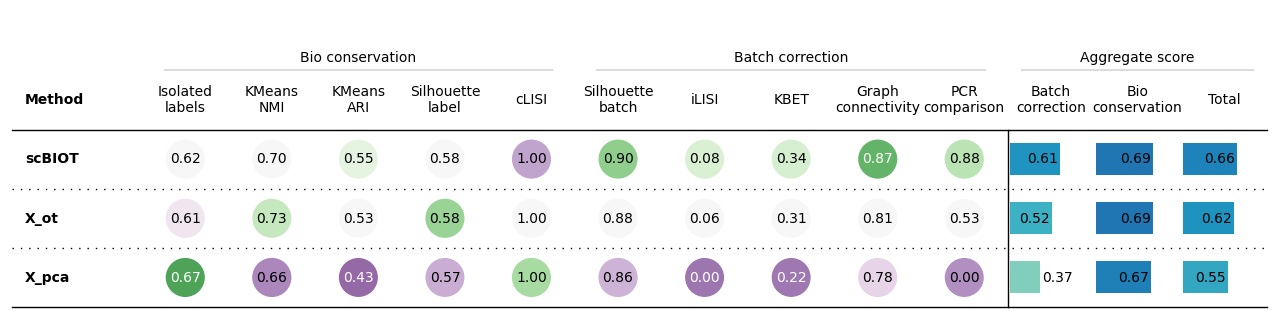

In [19]:
bm.plot_results_table(min_max_scale=False)